<a href="https://colab.research.google.com/github/sir-oh/web3-analytics-portfolio/blob/main/week2(project).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")

In [46]:
print(df.columns)

Index(['City', 'order id', 'Date', 'Store Code', 'Basket size', 'Delivery Fee',
       'Cost per order (CPO)', 'Distance in km (pick up to delivery)',
       'Courier waiting time (mins)', 'Delivery_Profit', 'Contribution',
       'High_CPO', 'Distance_Group', 'City_encoded'],
      dtype='object', name=0)


In [28]:
# LOAD DATA

df = pd.read_csv("Internship casestudy week 2 - Sheet1.csv")

# Remove duplicate columns
df = df.loc[:, ~df.columns.duplicated()]

In [30]:
import pandas as pd
import numpy as np

# CLEAN DATA

# Promote the first row to be the column headers
df.columns = df.iloc[0]
# Drop the first row since it is now the header
df = df[1:].reset_index(drop=True)

# Remove duplicate columns that might arise from promoting the header
df = df.loc[:, ~df.columns.duplicated()]

money_cols = ["Basket size", "Delivery Fee", "Cost per order (CPO)",
              "Distance in km (pick up to delivery)"]

for col in money_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("€", "", regex=False)
        .replace("", np.nan)
        .astype(float)
    )

df["Courier waiting time (mins)"] = pd.to_numeric(
    df["Courier waiting time (mins)"], errors="coerce"
)

df["Date"] = pd.to_datetime(df["Date"])

df = df.dropna()

In [31]:
# FEATURE ENGINEERING

df["Delivery_Profit"] = df["Delivery Fee"] - df["Cost per order (CPO)"]
df["Contribution"] = df["Basket size"] + df["Delivery Fee"] - df["Cost per order (CPO)"]
df["High_CPO"] = (df["Cost per order (CPO)"] > 4).astype(int)

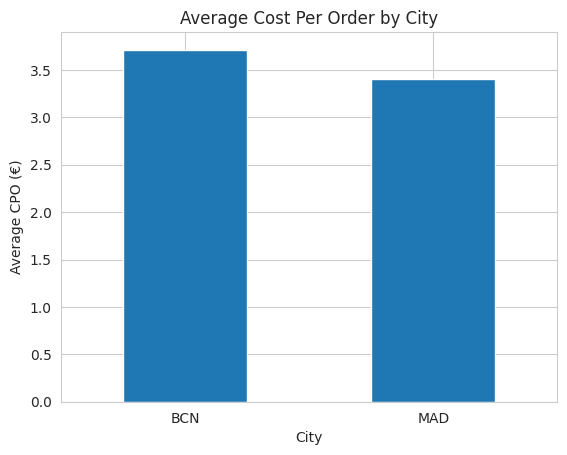

In [38]:
# VISUALIZE THE PROBLEMS

# Problem 1: Which City Has Higher Cost?
city_avg_cpo = df.groupby("City")["Cost per order (CPO)"].mean()

plt.figure()
city_avg_cpo.plot(kind="bar")
plt.title("Average Cost Per Order by City")
plt.ylabel("Average CPO (€)")
plt.xticks(rotation=0)
plt.show()

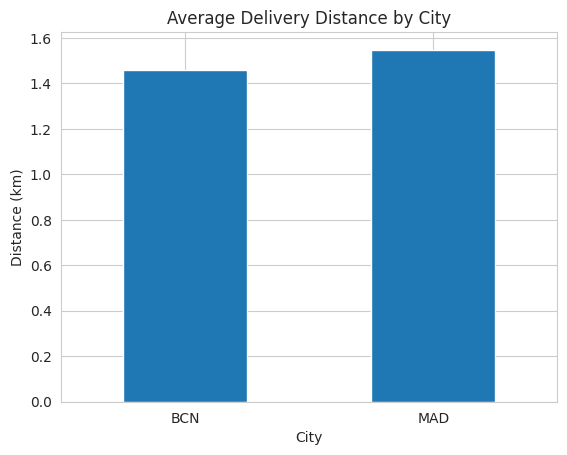

In [39]:
# Problem 2: Does Distance Increase Cost?

city_distance = df.groupby("City")["Distance in km (pick up to delivery)"].mean()

plt.figure()
city_distance.plot(kind="bar")
plt.title("Average Delivery Distance by City")
plt.ylabel("Distance (km)")
plt.xticks(rotation=0)
plt.show()

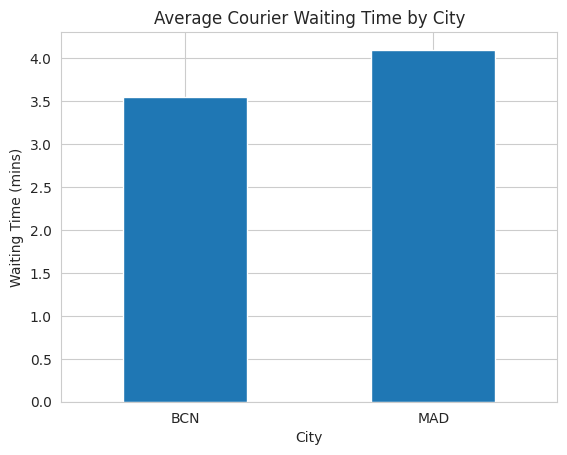

In [40]:
# Problem 3: Does Waiting Time Increase Cost?
city_wait = df.groupby("City")["Courier waiting time (mins)"].mean()

plt.figure()
city_wait.plot(kind="bar")
plt.title("Average Courier Waiting Time by City")
plt.ylabel("Waiting Time (mins)")
plt.xticks(rotation=0)
plt.show()

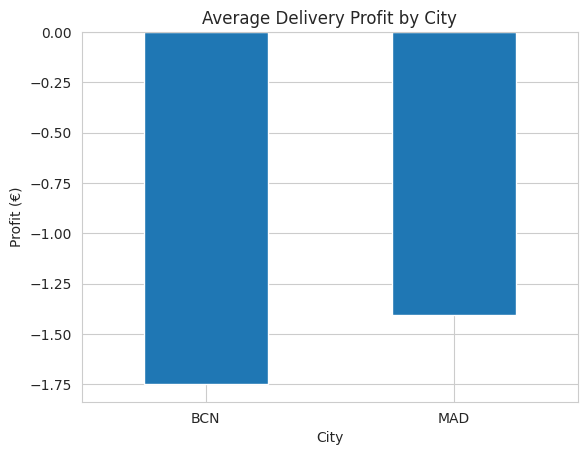

In [43]:
# Problem 4: Are We Losing Money?
city_profit = df.groupby("City")["Delivery_Profit"].mean()

plt.figure()
city_profit.plot(kind="bar")
plt.title("Average Delivery Profit by City")
plt.ylabel("Profit (€)")
plt.xticks(rotation=0)
plt.show()

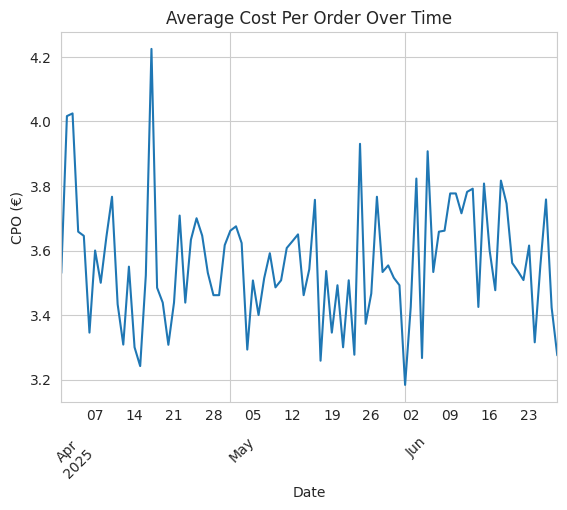

In [41]:
# Problem 5️: Cost Trend Over Time

daily_cpo = df.groupby("Date")["Cost per order (CPO)"].mean()

plt.figure()
daily_cpo.plot(kind="line")
plt.title("Average Cost Per Order Over Time")
plt.ylabel("CPO (€)")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_1139/2213318233.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distance_cpo = df.groupby("Distance_Group")["Cost per order (CPO)"].mean()


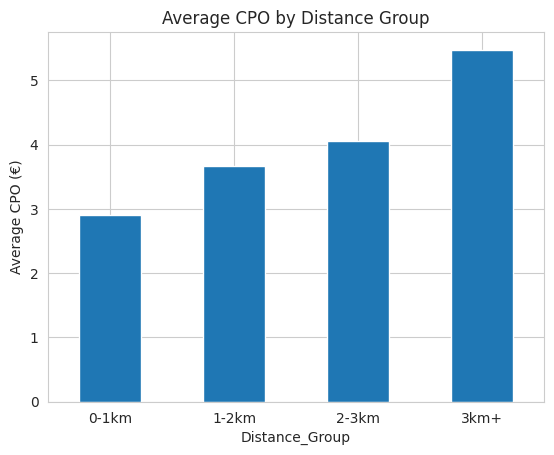

In [42]:
# Problem 6️: Distance Group Analysis

# Create distance buckets
df["Distance_Group"] = pd.cut(
    df["Distance in km (pick up to delivery)"],
    bins=[0, 1, 2, 3, 5],
    labels=["0-1km", "1-2km", "2-3km", "3km+"]
)

distance_cpo = df.groupby("Distance_Group")["Cost per order (CPO)"].mean()

plt.figure()
distance_cpo.plot(kind="bar")
plt.title("Average CPO by Distance Group")
plt.ylabel("Average CPO (€)")
plt.xticks(rotation=0)
plt.show()

In [45]:
# LINEAR REGRESSION MODEL


# Encode City
le = LabelEncoder()
df["City_encoded"] = le.fit_transform(df["City"])

X = df[[
    "Basket size",
    "Delivery Fee",
    "Distance in km (pick up to delivery)",
    "Courier waiting time (mins)",
    "City_encoded"
]]

y = df["Cost per order (CPO)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("R2:", round(r2_score(y_test, y_pred), 2))


# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print(importance)

MAE: 0.35
R2: 0.65
                                Feature  Coefficient
2  Distance in km (pick up to delivery)     0.714732
1                          Delivery Fee     0.094013
3           Courier waiting time (mins)    -0.012384
0                           Basket size    -0.019984
4                          City_encoded    -0.401295
